<a href="https://www.kaggle.com/code/lalit7881/college-student-health-behavior-eda?scriptVersionId=315227961" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session'

/kaggle/input/datasets/ziya07/college-student-health-behavior-dataset/enhanced_student_health_dataset_50k.xls
/kaggle/input/datasets/ziya07/college-student-health-behavior-dataset/student_health_dataset_50k.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/ziya07/college-student-health-behavior-dataset/student_health_dataset_50k.csv")

In [3]:
df.head()

,student_id,timestamp,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender,health_condition
0,1102,2025-01-01 00:00:00,9.29,67.4,28.56,2113.0,5227,91.3,2.08,veg,high,average,active,yes,other,at-risk
1,1435,2025-01-01 01:00:00,9.33,57.2,30.17,2060.0,14460,67.0,2.57,veg,medium,average,active,occasional,male,at-risk
2,1860,2025-01-01 02:00:00,8.33,73.7,19.93,2236.0,14589,52.6,1.93,non-veg,high,average,active,no,other,at-risk
3,1270,2025-01-01 03:00:00,5.60,61.9,22.02,2650.0,12618,55.2,2.97,veg,high,average,active,no,other,unhealthy
4,1106,2025-01-01 04:00:00,9.10,69.6,20.85,1985.0,14518,27.1,3.09,non-veg,medium,poor,sedentary,occasional,male,at-risk


In [4]:
df.tail()

,student_id,timestamp,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender,health_condition
49995,1381,2030-09-15 03:00:00,9.88,69.9,23.20,2311.0,7572,83.5,3.47,non-veg,low,average,sedentary,no,female,at-risk
49996,1044,2030-09-15 04:00:00,8.13,63.0,20.16,1819.0,13497,44.2,2.26,non-veg,low,good,sedentary,no,other,at-risk
49997,1916,2030-09-15 05:00:00,6.06,73.1,19.40,1917.0,5868,7.3,2.77,balanced,medium,poor,moderate,occasional,other,at-risk
49998,1171,2030-09-15 06:00:00,5.65,75.6,18.81,2067.0,10206,27.6,3.37,non-veg,low,good,moderate,yes,other,at-risk
49999,1220,2030-09-15 07:00:00,6.98,81.8,16.00,2266.0,3904,49.8,2.06,veg,low,poor,active,occasional,male,at-risk


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   student_id               50000 non-null  int64  
 1   timestamp                50000 non-null  object 
 2   sleep_duration           50000 non-null  float64
 3   heart_rate               50000 non-null  float64
 4   bmi                      50000 non-null  float64
 5   calorie_expenditure      50000 non-null  float64
 6   step_count               50000 non-null  int64  
 7   exercise_duration        50000 non-null  float64
 8   water_intake             50000 non-null  float64
 9   diet_type                50000 non-null  object 
 10  stress_level             50000 non-null  object 
 11  sleep_quality            50000 non-null  object 
 12  physical_activity_level  50000 non-null  object 
 13  smoking_alcohol          50000 non-null  object 
 14  gender                

In [6]:
df.describe()

,student_id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1501.943360,6.995989,75.002762,23.023812,2200.901460,7988.280340,40.098728,2.197891
std,289.067217,1.465308,9.930061,2.977059,398.811635,4044.517447,19.598865,0.696485
min,1000.000000,3.000000,50.000000,16.000000,1200.000000,1000.000000,0.000000,0.500000
25%,1252.000000,5.990000,68.300000,21.000000,1930.000000,4444.000000,26.400000,1.720000
50%,1505.000000,7.010000,75.000000,23.000000,2200.000000,8010.000000,39.900000,2.190000
75%,1753.000000,8.020000,81.700000,25.010000,2471.000000,11485.000000,53.400000,2.670000
max,1999.000000,10.000000,120.000000,35.000000,3901.000000,14999.000000,120.000000,4.940000


In [7]:
df.isnull().sum()

student_id                 0
timestamp                  0
sleep_duration             0
heart_rate                 0
bmi                        0
calorie_expenditure        0
step_count                 0
exercise_duration          0
water_intake               0
diet_type                  0
stress_level               0
sleep_quality              0
physical_activity_level    0
smoking_alcohol            0
gender                     0
health_condition           0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.columns

Index(['student_id', 'timestamp', 'sleep_duration', 'heart_rate', 'bmi',
       'calorie_expenditure', 'step_count', 'exercise_duration',
       'water_intake', 'diet_type', 'stress_level', 'sleep_quality',
       'physical_activity_level', 'smoking_alcohol', 'gender',
       'health_condition'],
      dtype='object')

In [10]:
df.dtypes

student_id                   int64
timestamp                   object
sleep_duration             float64
heart_rate                 float64
bmi                        float64
calorie_expenditure        float64
step_count                   int64
exercise_duration          float64
water_intake               float64
diet_type                   object
stress_level                object
sleep_quality               object
physical_activity_level     object
smoking_alcohol             object
gender                      object
health_condition            object
dtype: object

In [11]:
df.shape

(50000, 16)

In [12]:
df.nunique()

student_id                  1000
timestamp                  50000
sleep_duration               700
heart_rate                   585
bmi                         1627
calorie_expenditure         2179
step_count                 13601
exercise_duration           1041
water_intake                 412
diet_type                      3
stress_level                   3
sleep_quality                  3
physical_activity_level        3
smoking_alcohol                3
gender                         3
health_condition               3
dtype: int64

## EDA 

   student_id           timestamp  sleep_duration  heart_rate    bmi  \
0        1102 2025-01-01 00:00:00            9.29        67.4  28.56   
1        1435 2025-01-01 01:00:00            9.33        57.2  30.17   
2        1860 2025-01-01 02:00:00            8.33        73.7  19.93   
3        1270 2025-01-01 03:00:00            5.60        61.9  22.02   
4        1106 2025-01-01 04:00:00            9.10        69.6  20.85   

   calorie_expenditure  step_count  exercise_duration  water_intake diet_type  \
0               2113.0        5227               91.3          2.08       veg   
1               2060.0       14460               67.0          2.57       veg   
2               2236.0       14589               52.6          1.93   non-veg   
3               2650.0       12618               55.2          2.97       veg   
4               1985.0       14518               27.1          3.09   non-veg   

  stress_level sleep_quality physical_activity_level smoking_alcohol gender  \
0

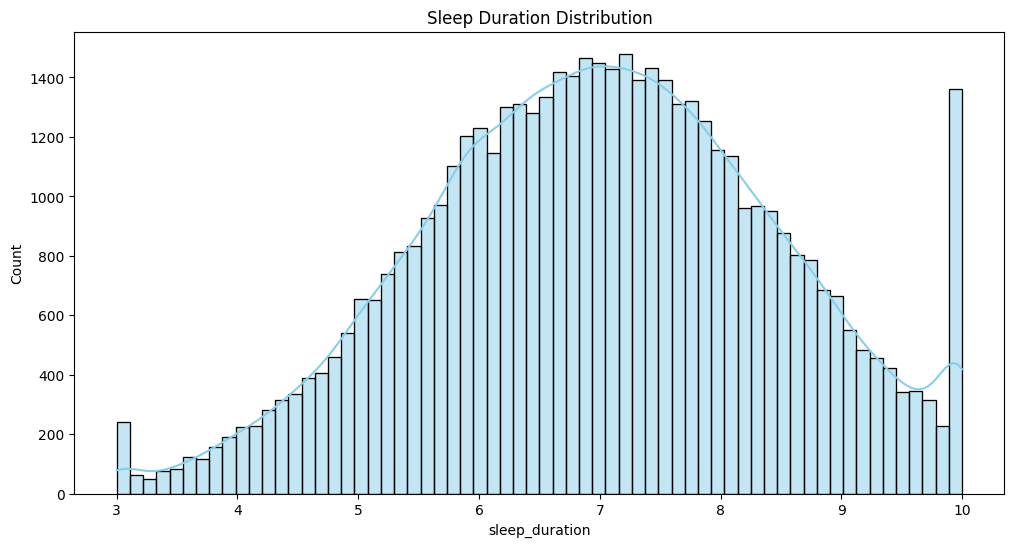

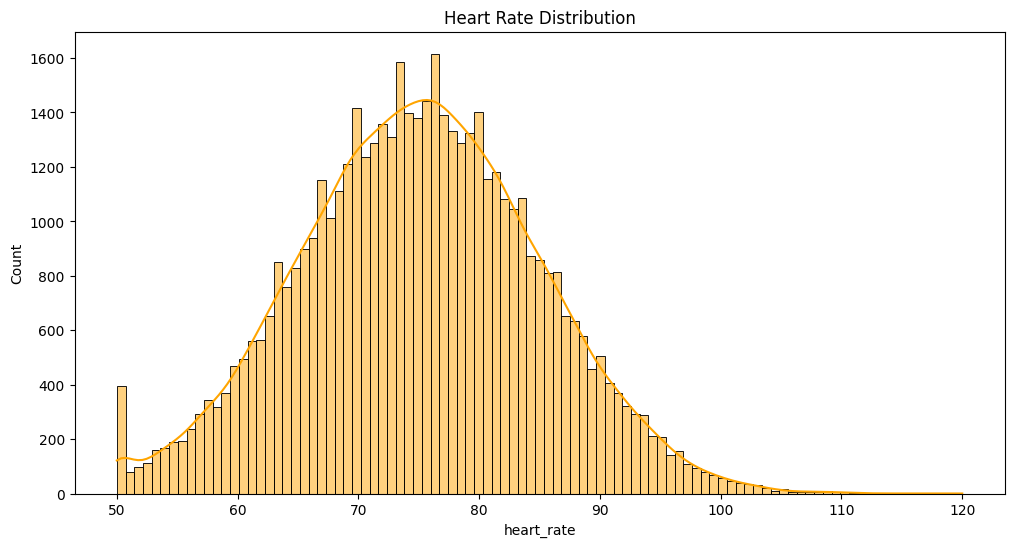

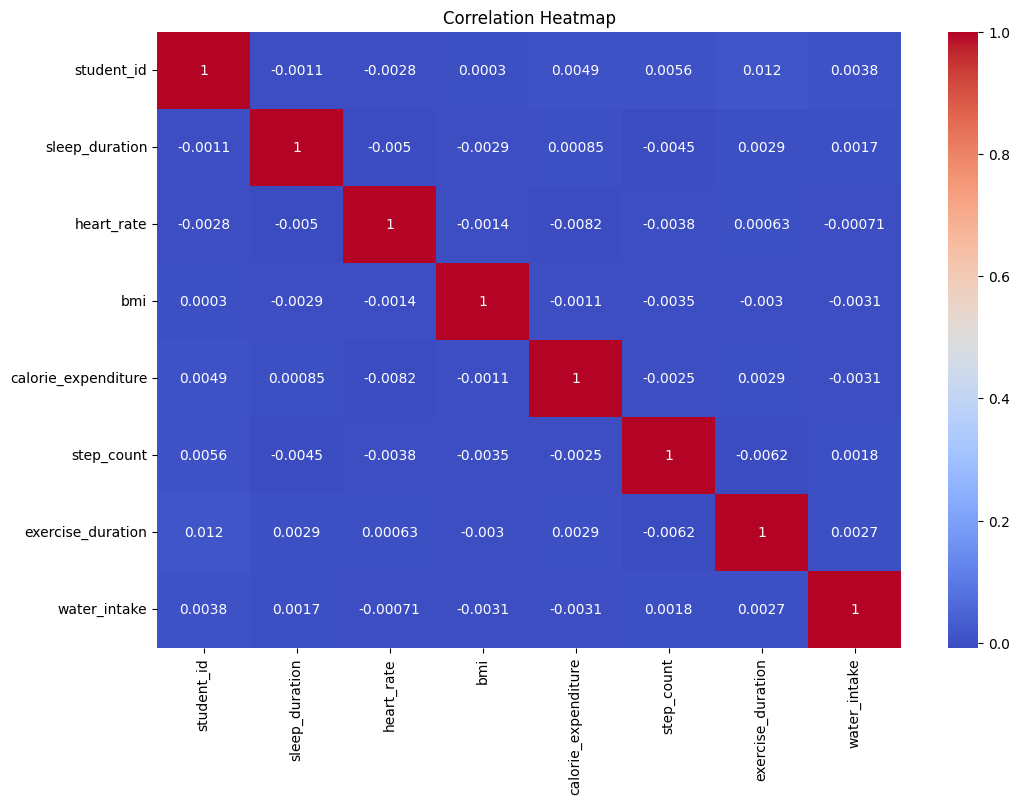

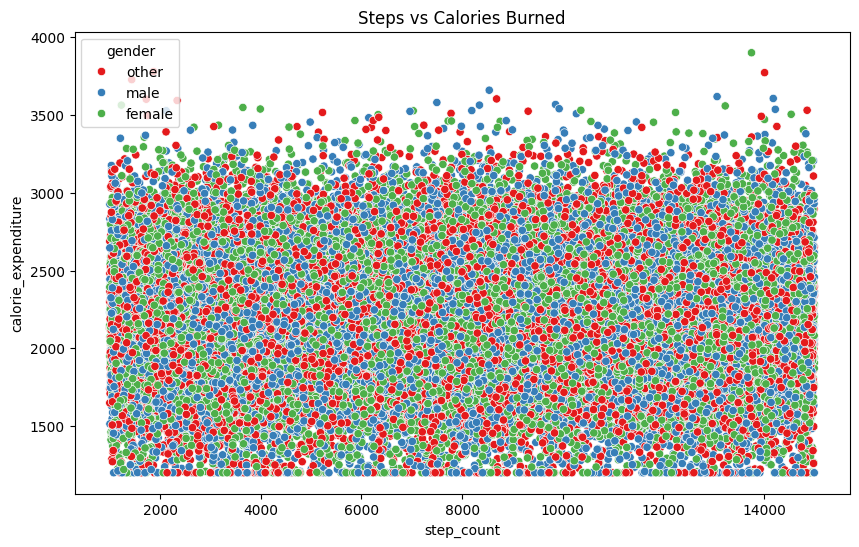

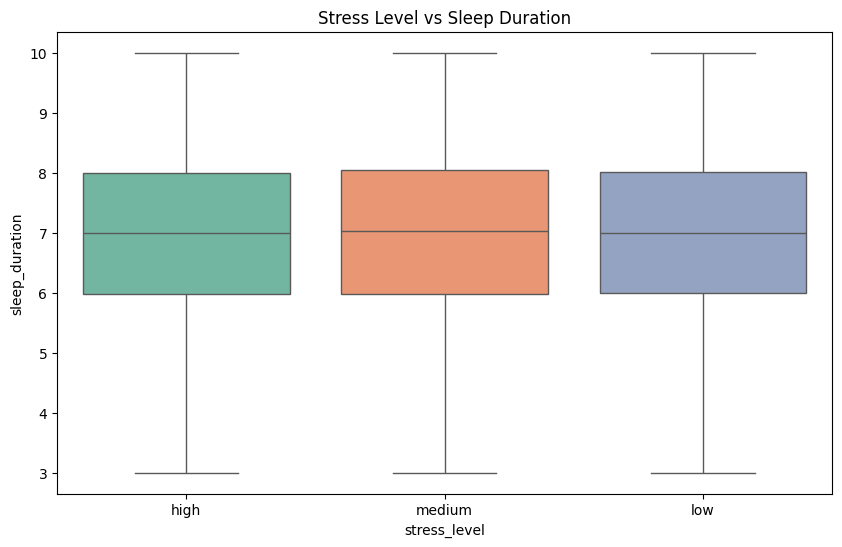

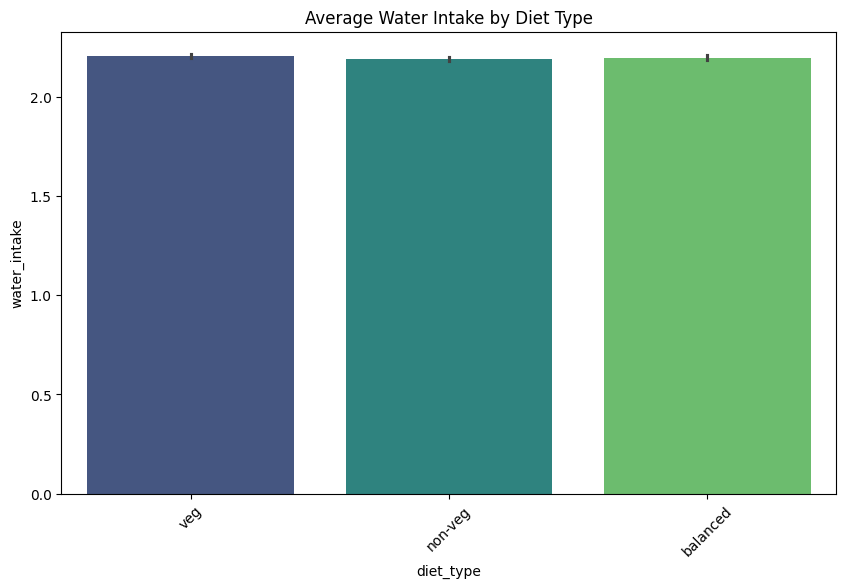

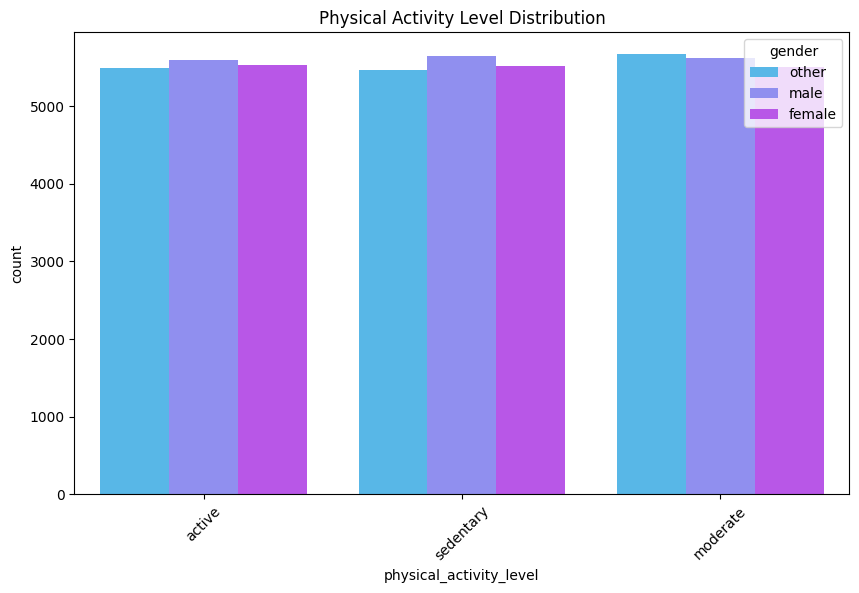

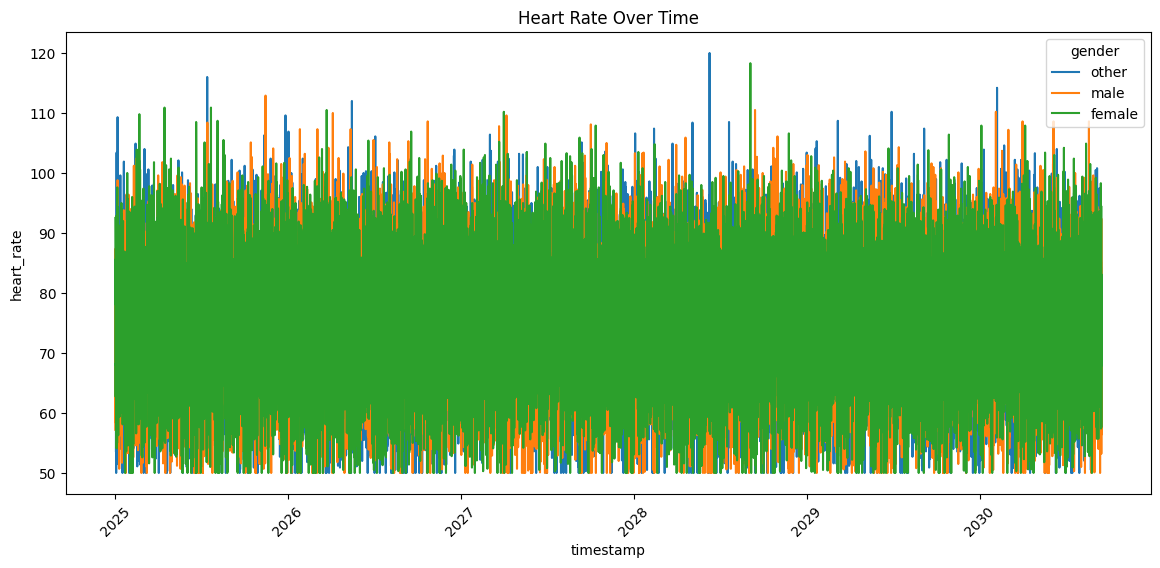

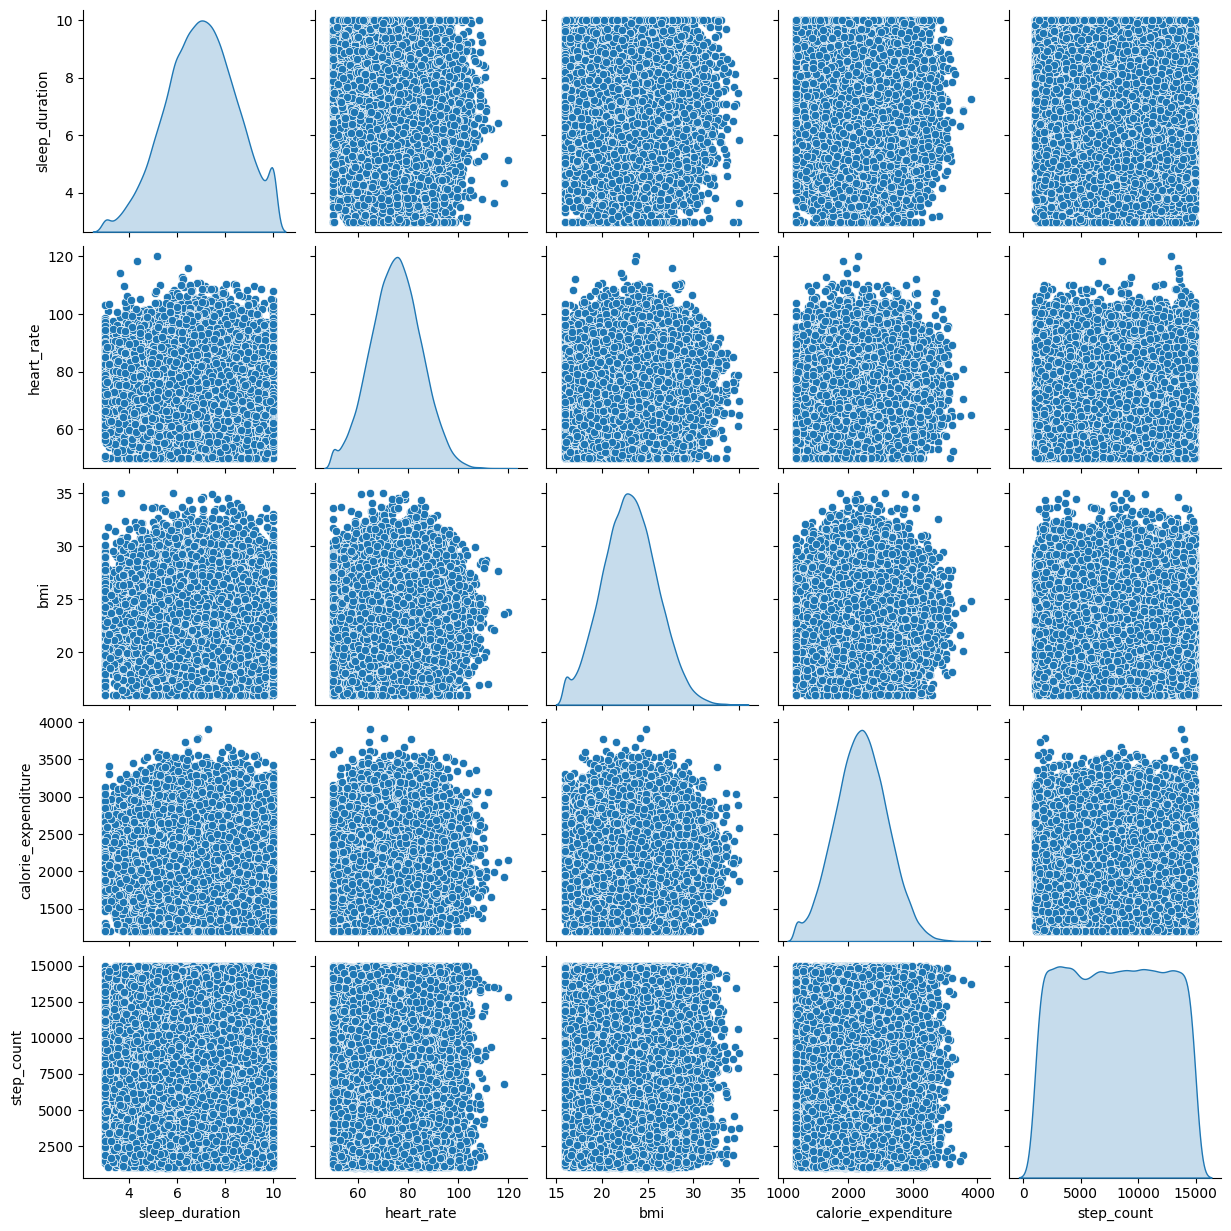

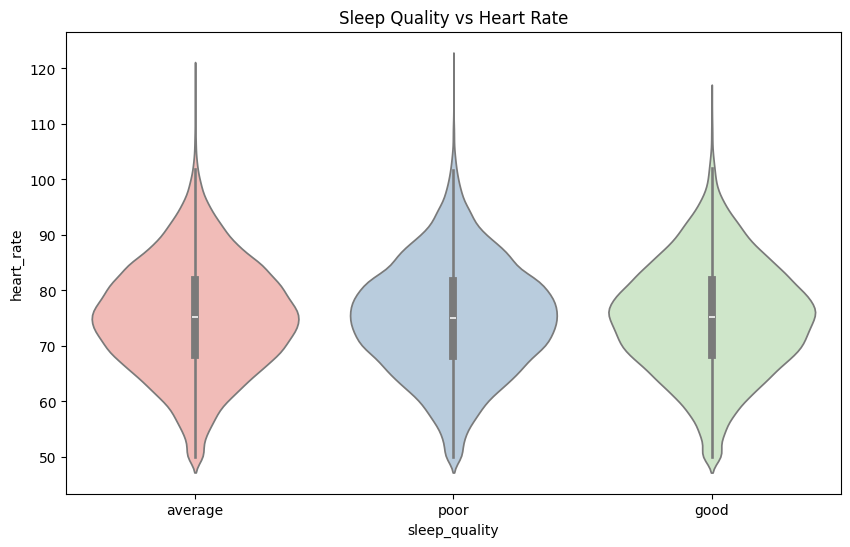

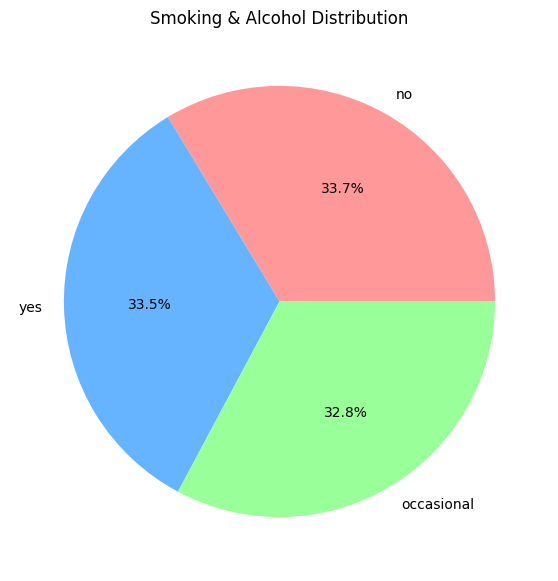

In [13]:
df.columns = df.columns.str.strip()

# Convert timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

# Convert numeric columns safely
num_cols = [
    'sleep_duration', 'heart_rate', 'bmi',
    'calorie_expenditure', 'step_count',
    'exercise_duration', 'water_intake'
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop missing values (important)
df = df.dropna()

# ==============================
# BASIC INFO
# ==============================
print(df.head())
print(df.info())

# ==============================
# 1. DISTRIBUTION PLOTS
# ==============================
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='sleep_duration', kde=True, color='skyblue')
plt.title("Sleep Duration Distribution")
plt.show()

plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='heart_rate', kde=True, color='orange')
plt.title("Heart Rate Distribution")
plt.show()

# ==============================
# 2. CORRELATION HEATMAP
# ==============================
plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# ==============================
# 3. SCATTER PLOT (FIXED)
# ==============================
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,   # ✅ FIXED
    x='step_count',
    y='calorie_expenditure',
    hue='gender',
    palette='Set1'
)
plt.title("Steps vs Calories Burned")
plt.show()

# ==============================
# 4. BOX PLOT
# ==============================
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x='stress_level',
    y='sleep_duration',
    palette='Set2'
)
plt.title("Stress Level vs Sleep Duration")
plt.show()

# ==============================
# 5. BAR PLOT
# ==============================
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df,
    x='diet_type',
    y='water_intake',
    estimator='mean',
    palette='viridis'
)
plt.title("Average Water Intake by Diet Type")
plt.xticks(rotation=45)
plt.show()

# ==============================
# 6. COUNT PLOT
# ==============================
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df,
    x='physical_activity_level',
    hue='gender',
    palette='cool'
)
plt.title("Physical Activity Level Distribution")
plt.xticks(rotation=45)
plt.show()

# ==============================
# 7. LINE PLOT (TIME SERIES)
# ==============================
df = df.sort_values('timestamp')

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=df,
    x='timestamp',
    y='heart_rate',
    hue='gender',
    palette='tab10'
)
plt.title("Heart Rate Over Time")
plt.xticks(rotation=45)
plt.show()

# ==============================
# 8. PAIRPLOT
# ==============================
sns.pairplot(
    df[['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count']],
    diag_kind='kde'
)
plt.show()

# ==============================
# 9. VIOLIN PLOT
# ==============================
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df,
    x='sleep_quality',
    y='heart_rate',
    palette='Pastel1'
)
plt.title("Sleep Quality vs Heart Rate")
plt.show()

# ==============================
# 10. PIE CHART
# ==============================
plt.figure(figsize=(7, 7))
df['smoking_alcohol'].value_counts().plot.pie(
    autopct='%1.1f%%',
    colors=['#ff9999','#66b3ff','#99ff99','#ffcc99']
)
plt.title("Smoking & Alcohol Distribution")
plt.ylabel('')
plt.show()

## Feature engineering

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      8744
           1       1.00      1.00      1.00       493
           2       1.00      1.00      1.00       763

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000

Confusion Matrix:
 [[8744    0    0]
 [   0  493    0]
 [   0    0  763]]


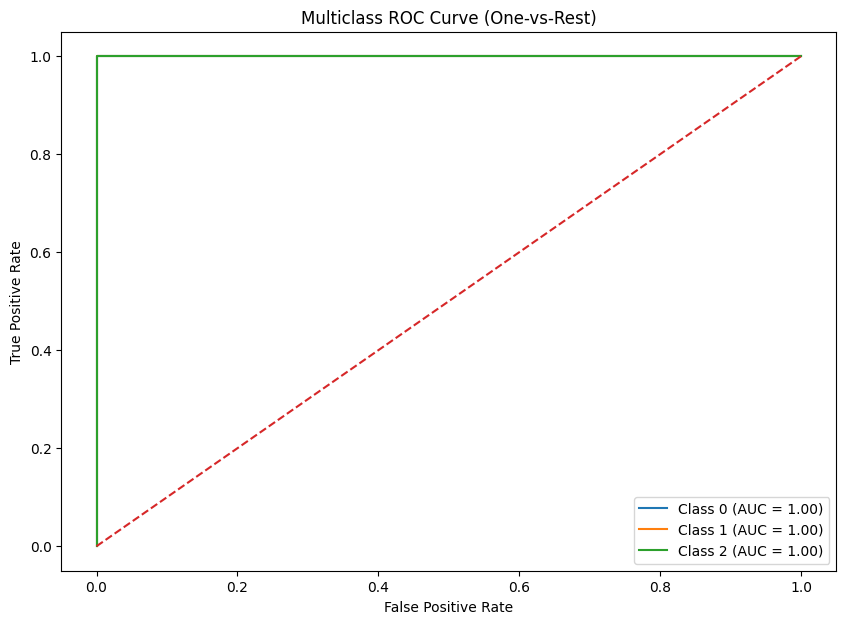

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

# ==============================
# CLEANING
# ==============================
df.columns = df.columns.str.strip()

if 'student_id' in df.columns:
    df = df.drop(columns=['student_id'])

# Timestamp → features
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df['hour'] = df['timestamp'].dt.hour
df['day'] = df['timestamp'].dt.day
df = df.drop(columns=['timestamp'])

df = df.dropna()

# ==============================
# TARGET
# ==============================
target = 'health_condition'

le = LabelEncoder()
df[target] = le.fit_transform(df[target])

X = df.drop(columns=[target])
y = df[target]

# ==============================
# ENCODE CATEGORICAL
# ==============================
cat_cols = X.select_dtypes(include='object').columns

for col in cat_cols:
    X[col] = LabelEncoder().fit_transform(X[col])

# ==============================
# SPLIT
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ==============================
# SCALE NUMERIC ONLY
# ==============================
num_cols = X.select_dtypes(include=['int64', 'float64']).columns

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols)
], remainder='passthrough')

# ==============================
# MODEL
# ==============================
model = RandomForestClassifier(n_estimators=200)

pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

# Train
pipe.fit(X_train, y_train)

# Predict
y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)

# ==============================
# METRICS
# ==============================
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# ==============================
# MULTICLASS ROC
# ==============================

# Binarize target
classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)

n_classes = y_test_bin.shape[1]

plt.figure(figsize=(10, 7))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

# Random baseline
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve (One-vs-Rest)")
plt.legend()
plt.show()

## Thank you...pls upvote!!!!!!!!!!!!